In [ ]:
# Import pandas
import pandas as pd

In [ ]:
# Reading the CSV file into a DataFrame
df=pd.read_csv('netflix_titles.csv')

In [ ]:
# Showing first 5 rows of DataFrame
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
# Showing quantity of rows and columns in DataFrame
print(f'quantity_of_rows: {df.shape[0]}, quantity_of_columns: {df.shape[1]}')

quantity_of_rows: 8807, quantity_of_columns: 12


In [ ]:
# Printing column names of DataFrame
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
# Printing types of data in each column of DataFrame
print(df.dtypes)

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [ ]:
# Printing null values in each column of DataFrame
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [15]:
# Basic cleaning of data

# 1. Text based columns filling with 'unknown'
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')
df['rating'] = df['rating'].fillna('unknown')

# 2. Date based columns filling with 'unknown'
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# 3. Extracting year and month from 'date_added' column
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# 4. Deleting missing values in 'duration' column due to small amount of missing data
df = df.dropna(subset=['duration'])

# 5. Cleaning verification

print('missing_values_after_cleaning:')
print(df.isnull().sum())

print('Size of DataFrame after cleaning:')
print(f'quantity_of_rows: {df.shape[0]}, quantity_of_columns: {df.shape[1]}')

missing_values_after_cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
month_added     98
dtype: int64
Size of DataFrame after cleaning:
quantity_of_rows: 8804, quantity_of_columns: 14


In [18]:
# Exploration of DataFrame

# 1. How many movies and TV shows are in the dataset?
print('quantity_of_movies:')
print(df['type'].value_counts())

# 2. What are the top 10 countries producing content?
print('top_10_countries:')
print(df['country'].value_counts().head(10))

# 3. How many titles were added each year?
print('titles_added_each_year:')
print(df['year_added'].value_counts().sort_index())

# 4. What rating appears the most often?
print('most_common_rating:')
print(df['rating'].value_counts())

quantity_of_movies:
type
Movie      6128
TV Show    2676
Name: count, dtype: int64
top_10_countries:
country
United States     2815
India              972
unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64
titles_added_each_year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     416
2017.0    1163
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64
most_common_rating:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
unknown        4
NC-17          3
UR             3
Name: count, dtype: int64


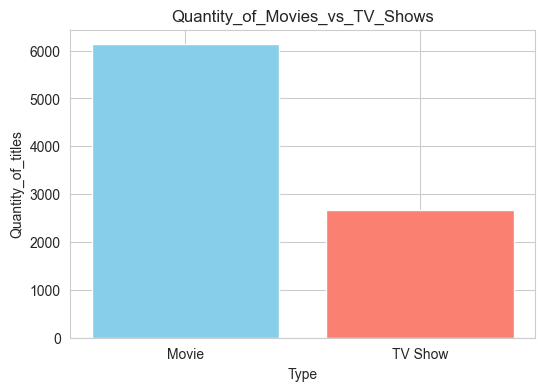

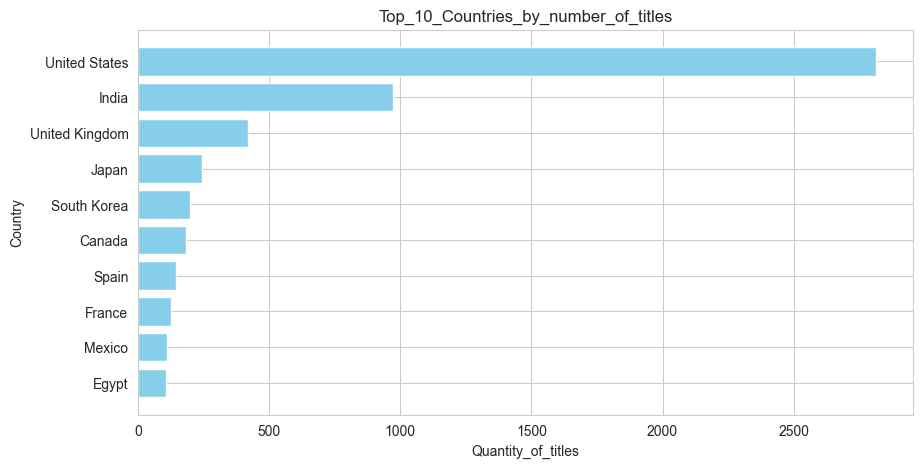

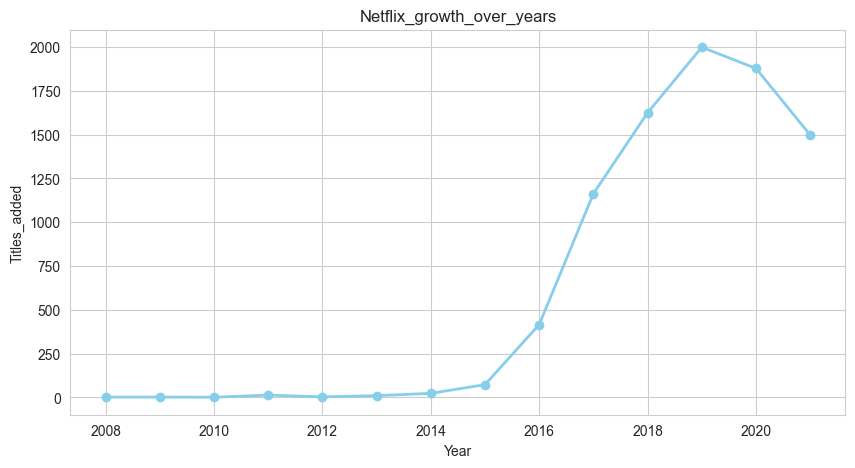

In [23]:
# Visualization of DataFrame

# 1. Importing libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 2. General style for all charts
sns.set_style('whitegrid')

# 3. Chart 1: Movies vs TV Shows

type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'salmon'])
plt.title('Quantity_of_Movies_vs_TV_Shows')
plt.ylabel('Quantity_of_titles')
plt.xlabel('Type')
# I will save this chart for future visuailization in PowerBI
plt.savefig('Chart_1_Type.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Chart 2: Top 10 Countries Produing Content, exluding 'unknown'

# I will filter out 'unknown' values to get a more accurate representation of top producing countries
top_countries = df[df['country'] != 'unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
# I will use barh to have country names on y-axis for better readability
plt.barh(top_countries.index, top_countries.values, color='skyblue')
# I will invert y-axis to have the most producing country on top
plt.gca().invert_yaxis()
plt.title('Top_10_Countries_by_number_of_titles')
plt.xlabel('Quantity_of_titles')
plt.ylabel('Country')
# I will save chart 2 for future visualization in PowerBI
plt.savefig('Chart_2_Top_Countries.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3: Titles added per year

# I will exlude empty values for better readability of the chart, and to get more accurate representation of titles added each year
added_yearly = df['year_added'].value_counts().sort_index().dropna()

plt.figure(figsize=(10, 5))
plt.plot(added_yearly.index, added_yearly.values, color='skyblue', marker='o', linewidth=2)
plt.title('Netflix_growth_over_years')
plt.xlabel('Year')
plt.ylabel('Titles_added')
# I will save chart 3 for future visualization in PowerBI
plt.savefig('Chart_3_Titles_added_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Exporting cleaned DataFrame to xlsx file for future visualization in PowerBI

df.to_excel('netflix_cleanded.xlsx', index=False)
